In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

from utils import load_trackmate_spots
from utils import load_trackmate_tracks
from utils import load_meanint_ROIs
from utils import remove_shorttracks_3
from utils import remove_shorttracks_spotsfile
from utils import split_table_by_track
from utils import first_10_frames
from utils import first_5_frames
from utils import meanint_tracks_ch2
from utils import meanint_tracks_ch1

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

In [3]:
# Loads spots file and removes first three rows

D14_merged_allROIs_spots_paths = ['/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_merged_spots.csv',
                                  '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-2_merged_spots.csv',
                                  '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-3_merged_spots.csv',
                                  '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-1_merged_spots.csv',
                                  '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-2_merged_spots.csv',
                                  '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-3_merged_spots.csv']

D14_raw_allROIs_spots_paths = ['/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_raw_spots.csv',
                               '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-2_raw_spots.csv',
                               '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-3_raw_spots.csv',
                               '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-1_raw_spots.csv',
                               '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-2_raw_spots.csv',
                               '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-3_raw_spots.csv']

D14_merged_allROIs_spots = []
D14_raw_allROIs_spots = []

for path in D14_merged_allROIs_spots_paths:
    df = load_trackmate_spots(path)
    D14_merged_allROIs_spots.append(df)
    
for path in D14_raw_allROIs_spots_paths:
    df = load_trackmate_spots(path)
    D14_raw_allROIs_spots.append(df)

D14_merged_allROIs_spots[0].head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,ID145474,145474,0,2377.77099609375,69.52926717,109.33712612999999,0.0,0.5,10,0.20172901499999998,1,NaN,NaN,0,NaN,8864.42857142857,8774.0,7566.0,10550.0,186153.0,781.6220040037621,9174.047619047618,8942.0,6681.0,11706.0,192655.0,1347.8035641810152,0.04677295894160387,1.013505975229374,0.06420338379168884,0.8212921419770106
1,ID145731,145731,0,3834.151611328125,69.39478116,109.74058416,0.0,1.3,26,0.20172901499999998,1,NaN,NaN,0,NaN,9000.619047619048,8542.0,7538.0,11747.0,189013.0,1204.3610951948954,8420.333333333334,7975.0,5686.0,14483.0,176827.0,2029.4421975836942,0.07308238747248288,1.0179473543005784,0.06437491817512855,0.5018855034453941
2,ID145670,145670,0,3191.315185546875,68.99132313,109.74058416,0.0,0.8500000000000001,17,0.20172901499999998,1,NaN,NaN,1,NaN,9038.238095238095,8761.0,7987.0,11350.0,189803.0,964.2102936995593,9087.095238095239,8625.0,5697.0,12683.0,190829.0,1707.996513601884,0.058918126921717065,1.0431062768110229,0.08034633198758759,0.7913546319427699
3,ID145863,145863,0,4912.9501953125,68.99132313,110.00955617999999,0.0,1.6,32,0.20172901499999998,1,NaN,NaN,0,NaN,8888.190476190477,8414.0,6788.0,12443.0,186652.0,1694.301968925481,8579.333333333334,8118.0,5956.0,13574.0,180166.0,2161.4972202927615,0.09137340401505928,0.8784134388933585,0.09280098261469531,0.674124876932153
4,ID145796,145796,0,1968.628173828125,69.26029514999999,109.74058416,0.0,1.4500000000000002,29,0.20172901499999998,1,NaN,NaN,0,NaN,8098.571428571428,8038.0,6963.0,9539.0,170070.0,736.1725050168997,8198.619047619048,8304.0,5542.0,11667.0,172171.0,1693.500265018889,0.0420093926053911,0.8870203594265038,0.06279297123663859,0.572068182721432


In [4]:
# Loads track file and removes first three rows

D14_merged_allROIs_tracks_paths = ['/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_merged_tracks.csv',
                                   '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-2_merged_tracks.csv',
                                   '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-3_merged_tracks.csv',
                                   '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-1_merged_tracks.csv',
                                   '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-2_merged_tracks.csv',
                                   '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-3_merged_tracks.csv']

D14_raw_allROIs_tracks_paths = ['/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_raw_tracks.csv',
                                '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-2_raw_tracks.csv',
                                '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-3_raw_tracks.csv',
                                '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-1_raw_tracks.csv',
                                '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-2_raw_tracks.csv',
                                '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-3_raw_tracks.csv']

D14_merged_allROIs_tracks = []
D14_raw_allROIs_tracks = []

for path in D14_merged_allROIs_tracks_paths:
    df = load_trackmate_tracks(path)
    D14_merged_allROIs_tracks.append(df)

for path in D14_raw_allROIs_tracks_paths:
    df = load_trackmate_tracks(path)
    D14_raw_allROIs_tracks.append(df)
    
D14_raw_allROIs_tracks[4].head()

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Track_265,0,0,NaN,NaN,8,0,0,0,0,0,0.35000000000000003,0.35000000000000003,0.7000000000000001,0.3007198603827177,125.20647531,37.57202904374999,0.0,3.3263593919022414,3.8038387858289697,2.689720199999923,3.8038387858288694,0.5955214337727286,5842.277648925781,1.1642257871657846,0.3007198603827177,0.25830029165974444,0.859199601093479,0.25830029165974444,20.943951023931955
1,Track_266,1,1,NaN,NaN,10,1,0,0,0,2,0.55,0.4,0.9500000000000001,0.9414020700000094,128.891391984,33.500465091,0.0,4.408584043533052,9.697924097751265,0.0,3.8038387858286646,3.2849797487181287,5427.569921875,2.073520159589866,1.1090000487957445,0.45401153475460543,1.7116401272727442,0.38825167227639623,15.35322063143867
2,Track_267,2,2,NaN,NaN,5,0,0,0,0,0,0.19999999999999996,0.6000000000000001,0.8,0.30071986038272086,126.82030743,36.66088632599999,0.0,7.714208953827171,13.44860100000004,5.3794404,6.014397207654425,3.834628025593672,4313.97275390625,1.5428417907654344,0.7242293281039414,0.1949129600861588,1.5035993019136047,0.19491296008615885,38.796917987858755
3,Track_268,3,3,NaN,NaN,6,1,0,0,0,1,0.30000000000000004,1.1500000000000001,1.4500000000000002,0.5545000243978869,128.860011915,33.03872979,0.0,3.007198603827192,6.014397207654502,0.0,3.0071986038272374,3.007198603827181,5174.840901692708,0.9021595811481593,0.5545000243978869,0.6146362971528679,1.8483334146596229,0.614636297152869,13.38972522294503
4,Track_269,4,4,NaN,NaN,29,3,0,0,0,2,1.5999999999999999,1.1500000000000001,2.75,1.3448601000000053,125.43834774103449,38.022441241034485,0.0,3.4129918161709236,8.505642100563735,0.0,3.8038387858288485,1.965442368801422,4965.0040914601295,5.12531560515338,1.6635000731936227,0.26239556811833814,0.8405375625000034,0.24627587986513622,21.168226825267244


In [5]:
# Loads mean intensites of each ROI per image

D14_allROIs_meanint_paths = ['/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/ROIs/Meanint_ROIs_pos14.csv',
                             '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/ROIs/Meanint_ROIs_pos19.csv']

D14_allROIs_meanint = []

for path in D14_allROIs_meanint_paths:
    df = load_meanint_ROIs(path)
    D14_allROIs_meanint.append(df)
    
D14_allROIs_meanint[1].head()

,,Label,Mean,StdDev
0,1,100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos...,5933.697,1414.005
1,2,100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos...,6004.464,1340.178
2,3,100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos...,5190.802,1483.487


In [6]:
# Removes tracks that are <= 3 from tracks file

D14_merged_allROIs_tracks_filtered = []
D14_raw_allROIs_tracks_filtered = []

for df in D14_merged_allROIs_tracks:
    df = remove_shorttracks_3(df)
    D14_merged_allROIs_tracks_filtered.append(df)
    
for df in D14_raw_allROIs_tracks:
    df = remove_shorttracks_3(df)
    D14_raw_allROIs_tracks_filtered.append(df)

#pd.set_option('display.max_rows', None) # Displays all rows of df    
D14_raw_allROIs_tracks_filtered[1].head()

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Track_234,1,1,NaN,NaN,4,1,0,0,0,1,0.2,0.0,0.2,0.13448601000000338,76.92599772,96.4600906725,0.0,0.8965734000000225,2.6897202000000675,0.0,0.0,1.552910681514813,3447.7828979492188,0.13448601000000338,0.13448601000000338,1.0,0.6724300500000169,0.75,0.0
1,Track_236,3,3,NaN,NaN,19,0,0,0,0,0,0.9,0.0,0.9,0.7841814548396916,80.1961312263158,91.86810125210525,0.0,4.488112635741263,9.697924097751265,2.689720199999781,3.8038387858289657,2.0508089465248065,6062.043161492598,4.039301372167136,0.7841814548396916,0.19413789232046538,0.8713127275996573,0.19413789232046536,31.62751888859497
2,Track_237,4,4,NaN,NaN,13,1,0,0,0,1,0.65,0.0,0.65,0.4252821050281784,77.79498424615385,100.73002148999998,0.0,4.636779786006064,8.505642100563842,0.0,5.379440400000142,2.5112237369017674,6526.522536057692,3.0593178838025756,0.7841814548396842,0.1390120677814541,0.6542801615818129,0.14110658512540306,18.445547201513786
3,Track_238,5,5,NaN,NaN,12,1,0,0,0,3,0.7000000000000001,0.0,0.7000000000000001,0.26897202000000675,80.87092068,88.48058741249999,0.0,2.2775805117557,6.014397207654475,0.0,2.689720200000068,2.278376189825685,4159.427510579427,1.3535337889656378,0.3803838785828969,0.19871836388033837,0.38424574285715246,0.16870786383790756,21.205750411731096
4,Track_240,7,7,NaN,NaN,6,1,0,0,0,2,0.35000000000000003,0.0,0.35000000000000003,1.0842608761602552,79.03294521,93.82640631,0.0,4.017530763870042,8.06916059999992,2.6897202000000653,2.835214033521189,2.312217724848221,4356.1111246744795,1.2879040943196296,1.0842608761602552,0.8418801376146301,3.0978882176007287,0.7710925938539841,11.307982268947917


In [7]:
# Creates trackIDs object 

D14_merged_allROIs_trackIDs = []
D14_raw_allROIs_trackIDs = []

for df in D14_merged_allROIs_tracks_filtered:
    ID = df["TRACK_ID"].unique()
    D14_merged_allROIs_trackIDs.append(ID)
    
for df in D14_raw_allROIs_tracks_filtered:
    ID = df["TRACK_ID"].unique()
    D14_raw_allROIs_trackIDs.append(ID)

D14_raw_allROIs_trackIDs[1]

array(['1', '3', '4', '5', '7', '8', '9', '11', '14', '17', '18', '19',
       '22', '28', '31', '32', '34', '36', '39', '40', '41', '43', '45',
       '47', '48', '52', '53', '56', '57'], dtype=object)

In [8]:
# Removes spots from spots file from tracks <= 3 in length

D14_merged_allROIs_spots_filtered = []
D14_raw_allROIs_spots_filtered = []


for df, i in zip(D14_merged_allROIs_spots, D14_merged_allROIs_trackIDs):
    
    df = remove_shorttracks_spotsfile(df, i)
    D14_merged_allROIs_spots_filtered.append(df)

for df, i in zip(D14_raw_allROIs_spots, D14_raw_allROIs_trackIDs):
    
    df = remove_shorttracks_spotsfile(df, i)
    D14_raw_allROIs_spots_filtered.append(df)


#pd.set_option('display.max_rows', None) # Displays all rows of df  
D14_raw_allROIs_spots_filtered[1].head(10)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
2,ID147920,147920,1,3218.324951171875,76.92599772,96.56095518,0.0,0.0,0,0.20172901499999998,1,NaN,NaN,0,NaN,9262.761904761905,9847.0,5921.0,11928.0,194518.0,1699.62848601575,0.05152324996030126,0.5340732977499526
3,ID147892,147892,1,3598.432373046875,76.92599772,96.42646916999999,0.0,0.05,1,0.20172901499999998,1,NaN,NaN,0,NaN,9629.142857142857,9400.0,7197.0,13179.0,202212.0,1295.7201582793364,0.07071417083152144,0.9816107660406231
4,ID147978,147978,1,3935.071044921875,76.92599772,96.42646916999999,0.0,0.15000000000000002,3,0.20172901499999998,1,NaN,NaN,0,NaN,9827.904761904761,9119.0,7311.0,13258.0,206386.0,1751.2836978845519,0.07422561959866047,0.775519559478189
5,ID148075,148075,1,3039.30322265625,76.92599772,96.42646916999999,0.0,0.2,4,0.20172901499999998,1,NaN,NaN,0,NaN,9197.52380952381,9496.0,6281.0,11051.0,193148.0,1354.6851892247003,0.06407371190105633,0.8176561429010637
8,ID147970,147970,3,7111.76806640625,80.15366196,91.98843083999999,0.0,0.15000000000000002,3,0.20172901499999998,1,NaN,NaN,0,NaN,11898.047619047618,11410.0,8884.0,18002.0,249859.0,2354.525418766815,0.07702429144343964,0.7227773399613313
9,ID148000,148000,3,4194.5498046875,80.15366196,91.98843083999999,0.0,0.35000000000000003,7,0.20172901499999998,1,NaN,NaN,0,NaN,11842.380952380952,12807.0,7890.0,14747.0,248690.0,2170.317729646756,0.05739140787101601,0.5923205583972457
10,ID147942,147942,3,5709.11865234375,80.15366196,92.12291685,0.0,0.1,2,0.20172901499999998,1,NaN,NaN,0,NaN,12332.142857142857,12248.0,8708.0,16282.0,258975.0,2223.368621837465,0.08556912997277431,0.8744131935873742
11,ID148294,148294,3,7297.0244140625,80.691606,91.98843083999999,0.0,0.8,16,0.20172901499999998,1,NaN,NaN,1,NaN,11425.095238095239,11583.0,8498.0,17163.0,239927.0,2261.428285503697,0.12979994690679084,1.1608603278647236
12,ID147911,147911,3,3218.52685546875,80.01917594999999,92.25740286,0.0,0.0,0,0.20172901499999998,1,NaN,NaN,0,NaN,10863.285714285714,11094.0,8342.0,13885.0,228129.0,1611.1964853132329,0.05354999714247609,0.6854045665055781
13,ID148132,148132,3,8011.86962890625,80.28814797,91.71945881999999,0.0,0.65,13,0.20172901499999998,1,NaN,NaN,1,NaN,10902.952380952382,10801.0,5870.0,16477.0,228962.0,3130.508209160144,0.11635889581582386,0.7260307548291016


In [9]:
# Splits tables into seperate dfs by TRACK_ID

D14_merged_pos14_ROI1_singletracks = [j for i,j in split_table_by_track(D14_merged_allROIs_spots_filtered[0])]
D14_merged_pos14_ROI2_singletracks = [j for i,j in split_table_by_track(D14_merged_allROIs_spots_filtered[1])]
D14_merged_pos14_ROI3_singletracks = [j for i,j in split_table_by_track(D14_merged_allROIs_spots_filtered[2])]
D14_merged_pos19_ROI1_singletracks = [j for i,j in split_table_by_track(D14_merged_allROIs_spots_filtered[3])]
D14_merged_pos19_ROI2_singletracks = [j for i,j in split_table_by_track(D14_merged_allROIs_spots_filtered[4])]
D14_merged_pos19_ROI3_singletracks = [j for i,j in split_table_by_track(D14_merged_allROIs_spots_filtered[5])]

D14_raw_pos14_ROI1_singletracks = [j for i,j in split_table_by_track(D14_raw_allROIs_spots_filtered[0])]
D14_raw_pos14_ROI2_singletracks = [j for i,j in split_table_by_track(D14_raw_allROIs_spots_filtered[1])]
D14_raw_pos14_ROI3_singletracks = [j for i,j in split_table_by_track(D14_raw_allROIs_spots_filtered[2])]
D14_raw_pos19_ROI1_singletracks = [j for i,j in split_table_by_track(D14_raw_allROIs_spots_filtered[3])]
D14_raw_pos19_ROI2_singletracks = [j for i,j in split_table_by_track(D14_raw_allROIs_spots_filtered[4])]
D14_raw_pos19_ROI3_singletracks = [j for i,j in split_table_by_track(D14_raw_allROIs_spots_filtered[5])]


D14_merged_allROIs_singletracks = [D14_merged_pos14_ROI1_singletracks, 
                                   D14_merged_pos14_ROI2_singletracks,
                                   D14_merged_pos14_ROI3_singletracks, 
                                   D14_merged_pos19_ROI1_singletracks,
                                   D14_merged_pos19_ROI2_singletracks,
                                   D14_merged_pos19_ROI3_singletracks]

D14_raw_allROIs_singletracks = [D14_raw_pos14_ROI1_singletracks, 
                                D14_raw_pos14_ROI2_singletracks,
                                D14_raw_pos14_ROI3_singletracks, 
                                D14_raw_pos19_ROI1_singletracks,
                                D14_raw_pos19_ROI2_singletracks,
                                D14_raw_pos19_ROI3_singletracks]

D14_raw_allROIs_singletracks[5][5].head(10)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
84,ID106641,106641,12,7602.25439453125,116.73385667999999,55.1392641,0.0,0.65,13,0.20172901499999998,1,NaN,NaN,0,NaN,10214.857142857143,9251.0,5790.0,15216.0,214512.0,3055.362307251208,0.13535582085404943,0.7971582083986515
85,ID106240,106240,12,4002.5009765625,116.86834268999999,55.004778089999995,0.0,0.55,11,0.20172901499999998,1,NaN,NaN,0,NaN,8429.238095238095,8541.0,3793.0,12216.0,177014.0,2009.1584781883657,0.07626677448750269,0.5945926940806266
86,ID106467,106467,12,7668.12158203125,116.86834268999999,54.87029208,0.0,0.6000000000000001,12,0.20172901499999998,1,NaN,NaN,0,NaN,9730.42857142857,8828.0,5319.0,15754.0,204339.0,3217.4507544238895,0.11602567516087937,0.6288252533259233
87,ID105746,105746,12,10191.6005859375,117.13731470999998,55.004778089999995,0.0,0.0,0,0.20172901499999998,1,NaN,NaN,0,NaN,10111.42857142857,10384.0,5953.0,18587.0,212340.0,3335.668847044451,0.16403225839608424,0.8543264126848211
88,ID106580,106580,12,4749.7236328125,117.0028287,55.1392641,0.0,0.75,15,0.20172901499999998,1,NaN,NaN,0,NaN,8233.809523809523,8440.0,5145.0,12857.0,172910.0,2077.016697550783,0.09179566795608755,0.6666097222242819
89,ID105991,105991,12,9246.267578125,117.0028287,54.87029208,0.0,0.05,1,0.20172901499999998,1,NaN,NaN,0,NaN,10692.57142857143,9637.0,7104.0,19706.0,224544.0,3014.350337492783,0.14621087551181755,0.9049687500530581
90,ID105929,105929,12,6657.49462890625,117.0028287,55.1392641,0.0,0.30000000000000004,6,0.20172901499999998,1,NaN,NaN,0,NaN,8644.57142857143,7856.0,5853.0,15680.0,181536.0,2629.1267860532816,0.1033200155892817,0.6158073938747294
91,ID106121,106121,12,4568.58837890625,117.13731470999998,55.004778089999995,0.0,0.35000000000000003,7,0.20172901499999998,1,NaN,NaN,0,NaN,8881.42857142857,8771.0,5628.0,13763.0,186510.0,1910.2213633877243,0.07828960062786039,0.6751461354936171
92,ID106525,106525,12,6894.63916015625,116.73385667999999,55.273750109999995,0.0,0.7000000000000001,14,0.20172901499999998,1,NaN,NaN,0,NaN,9477.047619047618,8530.0,6151.0,14295.0,199018.0,2491.050370349634,0.13549218991814063,0.9079264326048266
93,ID106063,106063,12,5193.39501953125,117.0028287,54.735806069999995,0.0,0.1,2,0.20172901499999998,1,NaN,NaN,0,NaN,9478.333333333334,8623.0,5665.0,14954.0,199045.0,2248.395813315203,0.09552511742241045,0.7351643631435418


In [10]:
# Sorts the seperated dfs by FRAME and extracts the first 10

D14_merged_pos14_ROI1_tracks10 = []
D14_merged_pos14_ROI2_tracks10 = []
D14_merged_pos14_ROI3_tracks10 = []
D14_merged_pos19_ROI1_tracks10 = []
D14_merged_pos19_ROI2_tracks10 = []
D14_merged_pos19_ROI3_tracks10 = []

D14_raw_pos14_ROI1_tracks10 = []
D14_raw_pos14_ROI2_tracks10 = []
D14_raw_pos14_ROI3_tracks10 = []
D14_raw_pos19_ROI1_tracks10 = []
D14_raw_pos19_ROI2_tracks10 = []
D14_raw_pos19_ROI3_tracks10 = []

D14_merged_allROIs_tracks10 = [D14_merged_pos14_ROI1_tracks10, 
                               D14_merged_pos14_ROI2_tracks10, 
                               D14_merged_pos14_ROI3_tracks10, 
                               D14_merged_pos19_ROI1_tracks10,
                               D14_merged_pos19_ROI2_tracks10,
                               D14_merged_pos19_ROI3_tracks10]

D14_raw_allROIs_tracks10 = [D14_raw_pos14_ROI1_tracks10, 
                            D14_raw_pos14_ROI2_tracks10, 
                            D14_raw_pos14_ROI3_tracks10, 
                            D14_raw_pos19_ROI1_tracks10,
                            D14_raw_pos19_ROI2_tracks10,
                            D14_raw_pos19_ROI3_tracks10]

for i in D14_merged_allROIs_singletracks:
    index = D14_merged_allROIs_singletracks.index(i)
    for j in i:
        j = first_10_frames(j)
        D14_merged_allROIs_tracks10[index].append(j)
        
for i in D14_raw_allROIs_singletracks:
    index = D14_raw_allROIs_singletracks.index(i)
    for j in i:
        j = first_10_frames(j)
        D14_raw_allROIs_tracks10[index].append(j)

D14_raw_allROIs_tracks10[0][2].head(11)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
37,ID141903,141903,2,4756.74365234375,64.82225681999999,119.69254889999999,0.0,0.25,5,0.20172901499999998,1,NaN,NaN,0,NaN,10053.142857142857,9743.0,7456.0,15500.0,211116.0,2001.1926765235348,0.10746181749510178,0.9749186187255445
34,ID141891,141891,2,4367.5400390625,64.82225681999999,119.55806288999999,0.0,0.30000000000000004,6,0.20172901499999998,1,NaN,NaN,0,NaN,9398.380952380952,8834.0,6338.0,12168.0,197366.0,1869.5409991810952,0.09203758329846354,0.8473750410642507
36,ID141941,141941,2,5679.95947265625,64.82225681999999,119.82703491,0.0,0.35000000000000003,7,0.20172901499999998,1,NaN,NaN,1,NaN,9450.47619047619,9438.0,4746.0,13780.0,198460.0,2210.3887128522806,0.09142229026272972,0.7162659586843435
38,ID141951,141951,2,4351.38427734375,64.82225681999999,119.69254889999999,0.0,0.4,8,0.20172901499999998,1,NaN,NaN,0,NaN,9318.095238095239,9746.0,6169.0,12286.0,195680.0,1804.5306842711736,0.09226142714605677,0.872341313111255
35,ID141878,141878,2,3092.66015625,64.82225681999999,119.69254889999999,0.0,0.45,9,0.20172901499999998,1,NaN,NaN,0,NaN,8777.809523809523,9145.0,5486.0,12013.0,184334.0,1679.735295189323,0.07247624754911937,0.7062904231271954
39,ID141916,141916,2,3418.30126953125,64.82225681999999,119.96152091999998,0.0,0.5,10,0.20172901499999998,1,NaN,NaN,0,NaN,7811.714285714285,7660.0,4944.0,10750.0,164046.0,1595.7427469005504,0.03449287014921838,0.32644896706589


In [11]:
# Concatenates all filtered seperate track dfs into one df per ROI

D14_merged_allROIs_alltracks10 = []
D14_raw_allROIs_alltracks10 = []

for i in D14_merged_allROIs_tracks10:
    for df in i:
        df = pd.concat(i)
    D14_merged_allROIs_alltracks10.append(df)
    
for i in D14_raw_allROIs_tracks10:
    for df in i:
        df = pd.concat(i)
    D14_raw_allROIs_alltracks10.append(df)
    
D14_raw_allROIs_alltracks10[4].head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
1,ID91107,91107,0,5506.76220703125,125.20647530999999,37.52159679,0.0,0.35000000000000003,7,0.20172901499999998,1,NaN,NaN,1,NaN,8366.47619047619,7986.0,4955.0,12138.0,175696.0,2090.487350333592,0.12530332883127032,0.8912879526292585
0,ID91121,91121,0,5241.54931640625,125.34096131999999,37.6560828,0.0,0.4,8,0.20172901499999998,1,NaN,NaN,1,NaN,8196.333333333334,7286.0,5355.0,12763.0,172123.0,2227.6069746104977,0.10341533853288135,0.6896948452442722
7,ID91133,91133,0,6196.3623046875,125.20647530999999,37.790568809999996,0.0,0.45,9,0.20172901499999998,1,NaN,NaN,1,NaN,8154.428571428572,7852.0,4935.0,14106.0,171243.0,2120.399622038935,0.10806233226728526,0.7500944555303242
3,ID91144,91144,0,6428.29931640625,125.07198929999998,37.790568809999996,0.0,0.5,10,0.20172901499999998,1,NaN,NaN,1,NaN,7991.0,7966.0,4135.0,12747.0,167811.0,2522.9776059251894,0.1264760744412251,0.7112202870642775
5,ID91162,91162,0,3717.23291015625,125.07198929999998,37.6560828,0.0,0.55,11,0.20172901499999998,1,NaN,NaN,0,NaN,7567.238095238095,7068.0,4371.0,10720.0,158912.0,1712.4215574665573,0.0830684508570947,0.6778551720880677


In [12]:
# Extracts the columns "TRACK_ID" and "MEAN_INTENSITY_CH2"(merged)/"MEAN_INTENSITY_CH1"(raw) and calculates the mean of each track

D14_merged_allROIs_meanint = []
D14_raw_allROIs_meanint = []

for df in D14_merged_allROIs_alltracks10:
    df = meanint_tracks_ch2(df)
    D14_merged_allROIs_meanint.append(df)
    
for df in D14_raw_allROIs_alltracks10:
    df = meanint_tracks_ch1(df)
    D14_raw_allROIs_meanint.append(df)
    
D14_raw_allROIs_meanint[5].head()

,TRACK_ID,MEAN_INTENSITY_CH1
0,1,10540.74
1,2,15190.03
2,3,13522.22
3,9,10975.27
4,10,9767.40


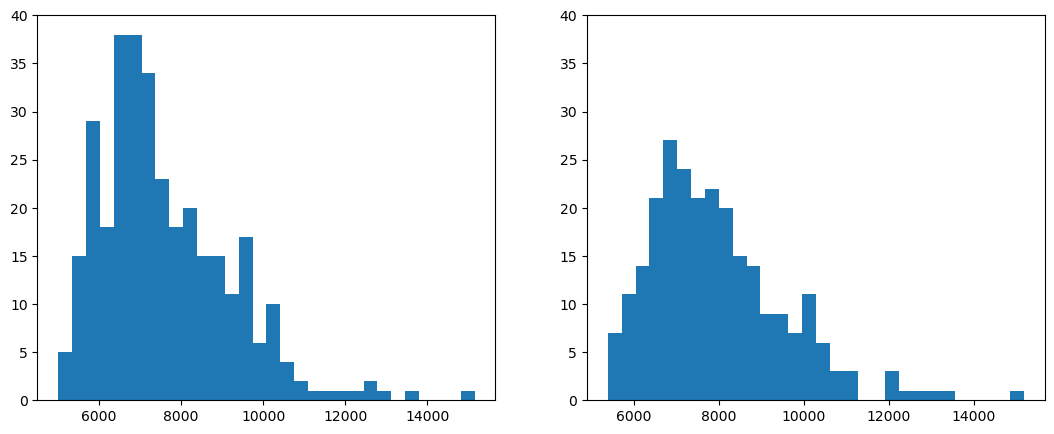

In [13]:
# Concatenates mean intensities of all ROIs per condition and plots them in a histogram

D14_raw_meanint = pd.concat(D14_raw_allROIs_meanint)
D14_merged_meanint = pd.concat(D14_merged_allROIs_meanint)


fig, ax = plt.subplots(1,2, figsize = (13,5)) # ; sign removes output lines
ax[0].hist(D14_merged_meanint["MEAN_INTENSITY_CH2"], 30);
ax[1].hist(D14_raw_meanint["MEAN_INTENSITY_CH1"], 30);
ax[0].set_ylim(0,40);
ax[1].set_ylim(0,40);

In [14]:
# Sorts the seperated dfs by FRAME and extracts the first 5

D14_merged_pos14_ROI1_tracks5 = []
D14_merged_pos14_ROI2_tracks5 = []
D14_merged_pos14_ROI3_tracks5 = []
D14_merged_pos19_ROI1_tracks5 = []
D14_merged_pos19_ROI2_tracks5 = []
D14_merged_pos19_ROI3_tracks5 = []

D14_raw_pos14_ROI1_tracks5 = []
D14_raw_pos14_ROI2_tracks5 = []
D14_raw_pos14_ROI3_tracks5 = []
D14_raw_pos19_ROI1_tracks5 = []
D14_raw_pos19_ROI2_tracks5 = []
D14_raw_pos19_ROI3_tracks5 = []

D14_merged_allROIs_tracks5 = [D14_merged_pos14_ROI1_tracks5, 
                              D14_merged_pos14_ROI2_tracks5, 
                              D14_merged_pos14_ROI3_tracks5, 
                              D14_merged_pos19_ROI1_tracks5,
                              D14_merged_pos19_ROI2_tracks5,
                              D14_merged_pos19_ROI3_tracks5]

D14_raw_allROIs_tracks5 = [D14_raw_pos14_ROI1_tracks5, 
                           D14_raw_pos14_ROI2_tracks5, 
                           D14_raw_pos14_ROI3_tracks5, 
                           D14_raw_pos19_ROI1_tracks5,
                           D14_raw_pos19_ROI2_tracks5,
                           D14_raw_pos19_ROI3_tracks5]

for i in D14_merged_allROIs_singletracks:
    index = D14_merged_allROIs_singletracks.index(i)
    for j in i:
        j = first_5_frames(j)
        D14_merged_allROIs_tracks5[index].append(j)
        
for i in D14_raw_allROIs_singletracks:
    index = D14_raw_allROIs_singletracks.index(i)
    for j in i:
        j = first_5_frames(j)
        D14_raw_allROIs_tracks5[index].append(j)

D14_raw_allROIs_tracks5[0][2].head(11)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
37,ID141903,141903,2,4756.74365234375,64.82225681999999,119.69254889999999,0.0,0.25,5,0.20172901499999998,1,NaN,NaN,0,NaN,10053.142857142857,9743.0,7456.0,15500.0,211116.0,2001.1926765235348,0.10746181749510178,0.9749186187255445
34,ID141891,141891,2,4367.5400390625,64.82225681999999,119.55806288999999,0.0,0.30000000000000004,6,0.20172901499999998,1,NaN,NaN,0,NaN,9398.380952380952,8834.0,6338.0,12168.0,197366.0,1869.5409991810952,0.09203758329846354,0.8473750410642507
36,ID141941,141941,2,5679.95947265625,64.82225681999999,119.82703491,0.0,0.35000000000000003,7,0.20172901499999998,1,NaN,NaN,1,NaN,9450.47619047619,9438.0,4746.0,13780.0,198460.0,2210.3887128522806,0.09142229026272972,0.7162659586843435
38,ID141951,141951,2,4351.38427734375,64.82225681999999,119.69254889999999,0.0,0.4,8,0.20172901499999998,1,NaN,NaN,0,NaN,9318.095238095239,9746.0,6169.0,12286.0,195680.0,1804.5306842711736,0.09226142714605677,0.872341313111255
35,ID141878,141878,2,3092.66015625,64.82225681999999,119.69254889999999,0.0,0.45,9,0.20172901499999998,1,NaN,NaN,0,NaN,8777.809523809523,9145.0,5486.0,12013.0,184334.0,1679.735295189323,0.07247624754911937,0.7062904231271954


In [15]:
# Concatenates all filtered seperate track dfs into one df per ROI

D14_merged_allROIs_alltracks5 = []
D14_raw_allROIs_alltracks5 = []

for i in D14_merged_allROIs_tracks5:
    for df in i:
        df = pd.concat(i)
    D14_merged_allROIs_alltracks5.append(df)
    
for i in D14_raw_allROIs_tracks5:
    for df in i:
        df = pd.concat(i)
    D14_raw_allROIs_alltracks5.append(df)
    
D14_raw_allROIs_alltracks5[4].head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
1,ID91107,91107,0,5506.76220703125,125.20647530999999,37.52159679,0.0,0.35000000000000003,7,0.20172901499999998,1,NaN,NaN,1,NaN,8366.47619047619,7986.0,4955.0,12138.0,175696.0,2090.487350333592,0.12530332883127032,0.8912879526292585
0,ID91121,91121,0,5241.54931640625,125.34096131999999,37.6560828,0.0,0.4,8,0.20172901499999998,1,NaN,NaN,1,NaN,8196.333333333334,7286.0,5355.0,12763.0,172123.0,2227.6069746104977,0.10341533853288135,0.6896948452442722
7,ID91133,91133,0,6196.3623046875,125.20647530999999,37.790568809999996,0.0,0.45,9,0.20172901499999998,1,NaN,NaN,1,NaN,8154.428571428572,7852.0,4935.0,14106.0,171243.0,2120.399622038935,0.10806233226728526,0.7500944555303242
3,ID91144,91144,0,6428.29931640625,125.07198929999998,37.790568809999996,0.0,0.5,10,0.20172901499999998,1,NaN,NaN,1,NaN,7991.0,7966.0,4135.0,12747.0,167811.0,2522.9776059251894,0.1264760744412251,0.7112202870642775
5,ID91162,91162,0,3717.23291015625,125.07198929999998,37.6560828,0.0,0.55,11,0.20172901499999998,1,NaN,NaN,0,NaN,7567.238095238095,7068.0,4371.0,10720.0,158912.0,1712.4215574665573,0.0830684508570947,0.6778551720880677


In [16]:
# Extracts the columns "TRACK_ID" and "MEAN_INTENSITY_CH2"(merged)/"MEAN_INTENSITY_CH1"(raw) and calculates the mean of each track

D14_merged_allROIs_meanint5 = []
D14_raw_allROIs_meanint5 = []

for df in D14_merged_allROIs_alltracks5:
    df = meanint_tracks_ch2(df)
    D14_merged_allROIs_meanint5.append(df)
    
for df in D14_raw_allROIs_alltracks5:
    df = meanint_tracks_ch1(df)
    D14_raw_allROIs_meanint5.append(df)
    
D14_raw_allROIs_meanint5[5].head()

,TRACK_ID,MEAN_INTENSITY_CH1
0,1,11775.22
1,2,15563.57
2,3,14115.42
3,9,11659.10
4,10,9890.70


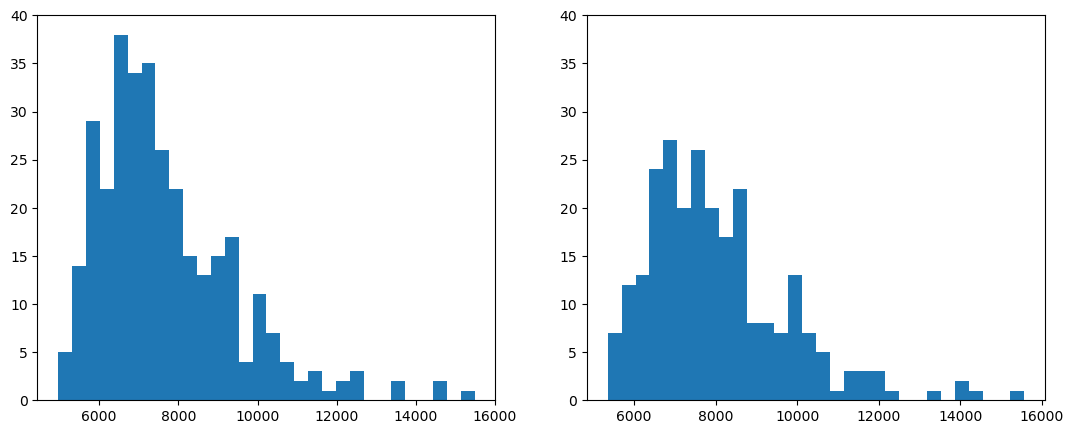

In [17]:
# Concatenates mean intensities of all ROIs per condition and plots them in a histogram

D14_raw_meanint5 = pd.concat(D14_raw_allROIs_meanint5)
D14_merged_meanint5 = pd.concat(D14_merged_allROIs_meanint5)


fig, ax = plt.subplots(1,2, figsize = (13,5)) # ; sign removes output lines
ax[0].hist(D14_merged_meanint5["MEAN_INTENSITY_CH2"], 30);
ax[1].hist(D14_raw_meanint5["MEAN_INTENSITY_CH1"], 30);
ax[0].set_ylim(0,40);
ax[1].set_ylim(0,40);

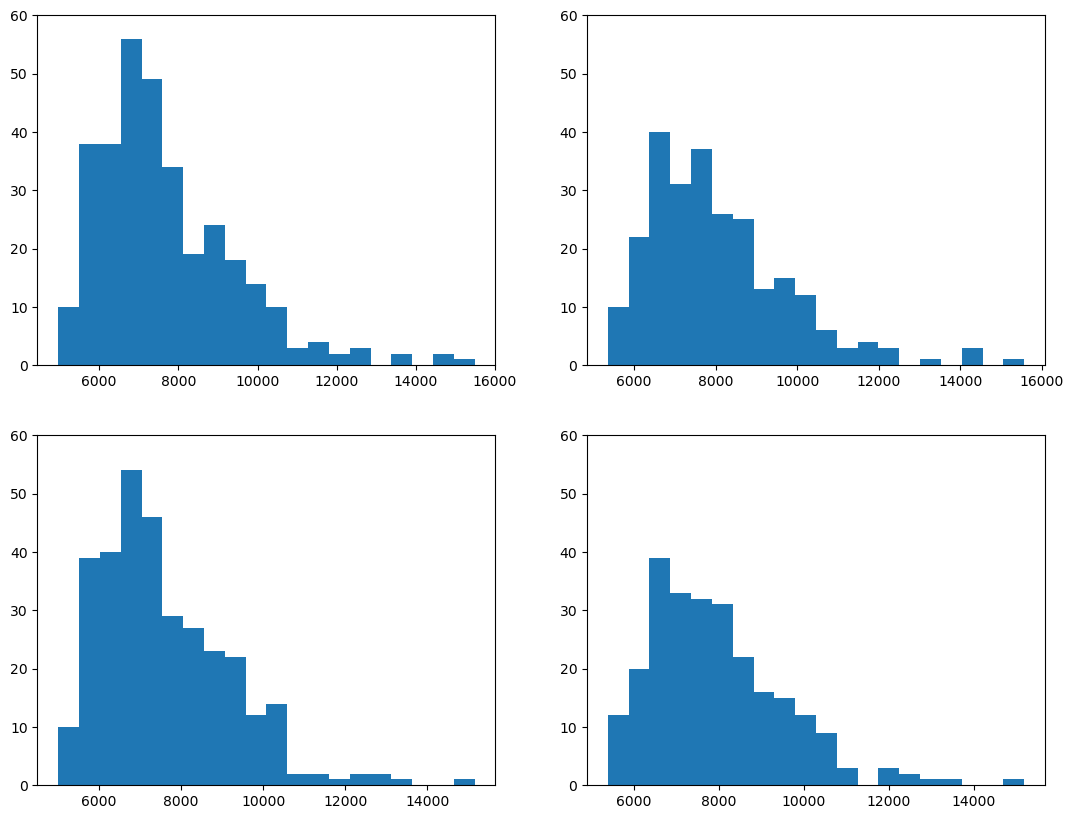

In [18]:
# Plots mean intensities of all ROIs per condition

fig, ax = plt.subplots(2,2, figsize = (13,10)) # ; sign removes output lines
ax[0][0].hist(D14_merged_meanint5["MEAN_INTENSITY_CH2"], 20);
ax[0][1].hist(D14_raw_meanint5["MEAN_INTENSITY_CH1"], 20);
ax[1][0].hist(D14_merged_meanint["MEAN_INTENSITY_CH2"], 20);
ax[1][1].hist(D14_raw_meanint["MEAN_INTENSITY_CH1"], 20);
ax[0][0].set_ylim(0,60);
ax[0][1].set_ylim(0,60);
ax[1][0].set_ylim(0,60);
ax[1][1].set_ylim(0,60);

In [19]:
# Creates a list containing the number of tracks per ROI after removal of short tracks

D14_merged_allROIs_trackNo = []

for df in D14_merged_allROIs_tracks_filtered:
    no = df.shape[0]
    D14_merged_allROIs_trackNo.append(no)
    
D14_raw_allROIs_trackNo = []

for df in D14_raw_allROIs_tracks_filtered:
    no = df.shape[0]
    D14_raw_allROIs_trackNo.append(no)
    
print(D14_merged_allROIs_trackNo)
print(D14_raw_allROIs_trackNo)

[27, 42, 17, 67, 14, 160]
[23, 29, 8, 43, 11, 138]


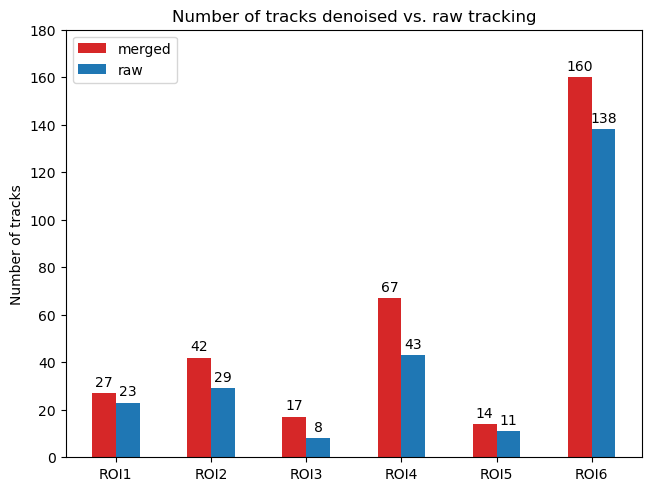

In [20]:
# Plots number of tracks per ROI after removal of short tracks

# Creates x values and stores y values in dictionary based on category
ROIs = ("ROI1", "ROI2", "ROI3", "ROI4", "ROI5", "ROI6")
trackNOs = {
    'merged': tuple(D14_merged_allROIs_trackNo),
    'raw': tuple((D14_raw_allROIs_trackNo)),
} 
# print(trackNOs)

x = np.arange(len(ROIs))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0.5 # places the data on the x axis
index = 0 # to access different data categories in for loop
bar_colours = ["tab:red", "tab:blue"]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in trackNOs.items():

    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=bar_colours[index]) # offset is needed to plot bars next to each other
    ax.bar_label(rects, padding = 3) # adds numbers to bars
    multiplier += 1
    index += 1
    
# Text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of tracks')
ax.set_title('Number of tracks denoised vs. raw tracking')
ax.set_xticks(x + width, ROIs)
ax.legend(loc='upper left', ncols=1)
ax.set_ylim(0, 180)

plt.show()

In [21]:
D14_merged_allROIs_trackNo_unfiltered = []

for df in D14_merged_allROIs_tracks:
    no = df.shape[0]
    D14_merged_allROIs_trackNo_unfiltered.append(no)
    
D14_raw_allROIs_trackNo_unfiltered = []

for df in D14_raw_allROIs_tracks:
    no = df.shape[0]
    D14_raw_allROIs_trackNo_unfiltered.append(no)
    
print(D14_merged_allROIs_trackNo_unfiltered)
print(D14_raw_allROIs_trackNo_unfiltered)

[43, 66, 40, 116, 22, 208]
[35, 62, 23, 83, 20, 191]


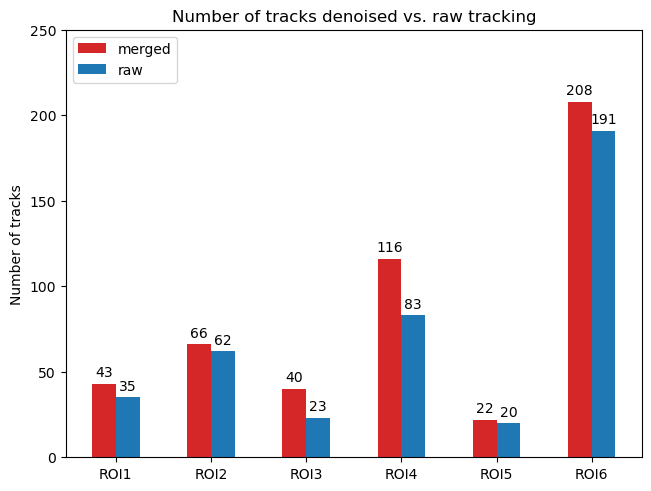

In [22]:
# Plots number of tracks per ROI before removal of short tracks

# Creates x values and stores y values in dictionary based on category
ROIs = ("ROI1", "ROI2", "ROI3", "ROI4", "ROI5", "ROI6")
trackNOs_unf = {
    'merged': tuple(D14_merged_allROIs_trackNo_unfiltered),
    'raw': tuple((D14_raw_allROIs_trackNo_unfiltered)),
} 
# print(trackNOs_unf)

x = np.arange(len(ROIs))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0.5 # places the data on the x axis
index = 0 # to access different data categories in for loop
bar_colours = ["tab:red", "tab:blue"]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in trackNOs_unf.items():

    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=bar_colours[index]) # offset is needed to plot bars next to each other
    ax.bar_label(rects, padding = 3) # adds numbers to bars
    multiplier += 1
    index += 1
    
# Text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of tracks')
ax.set_title('Number of tracks denoised vs. raw tracking')
ax.set_xticks(x + width, ROIs)
ax.legend(loc='upper left', ncols=1)
ax.set_ylim(0, 250)

plt.show()

In [23]:
# Calculates percentage of remaining tracks after removal of short tracks

D14_merged_allROIs_trackNo_diff = []

index = 0
for i in D14_merged_allROIs_trackNo:
    i = D14_merged_allROIs_trackNo[index] / D14_merged_allROIs_trackNo_unfiltered[index] * 100
    i = round(i, 2)
    D14_merged_allROIs_trackNo_diff.append(i)
    index += 1
    

D14_raw_allROIs_trackNo_diff = []

index = 0
for i in D14_raw_allROIs_trackNo:
    i = D14_raw_allROIs_trackNo[index] / D14_raw_allROIs_trackNo_unfiltered[index] * 100
    i = round(i, 2)
    D14_raw_allROIs_trackNo_diff.append(i)
    index += 1

print(D14_merged_allROIs_trackNo_diff)
print(D14_raw_allROIs_trackNo_diff)

[62.79, 63.64, 42.5, 57.76, 63.64, 76.92]
[65.71, 46.77, 34.78, 51.81, 55.0, 72.25]


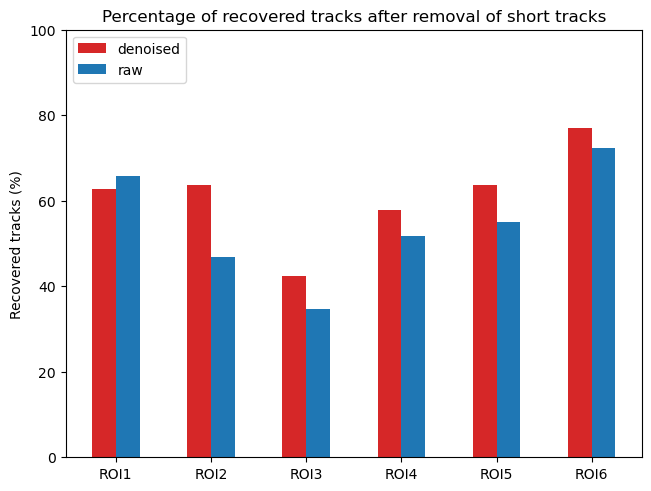

In [24]:
# Plots number of tracks per ROI before removal of short tracks

# Creates x values and stores y values in dictionary based on category

ROIs = ("ROI1", "ROI2", "ROI3", "ROI4", "ROI5", "ROI6")

trackNOs_diff = {
    'denoised': tuple(D14_merged_allROIs_trackNo_diff),
    'raw': tuple((D14_raw_allROIs_trackNo_diff)),
} 

x = np.arange(len(ROIs))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0.5 # places the data on the x axis
index = 0 # to access different data categories in for loop
bar_colours = ["tab:red", "tab:blue"]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in trackNOs_diff.items():

    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=bar_colours[index]) # offset is needed to plot bars next to each other
    multiplier += 1
    index += 1
    
# Text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Recovered tracks (%)')
ax.set_title('Percentage of recovered tracks after removal of short tracks')
ax.set_xticks(x + width, ROIs)
ax.legend(loc='upper left', ncols=1)
ax.set_ylim(0, 100)

plt.show()

In [25]:
# Calculates the length of each track

D14_merged_allROIs_tracklen = []
D14_raw_allROIs_tracklen = []

for i in D14_merged_allROIs_singletracks:
    for df in i:
        x = df.shape[0]
        D14_merged_allROIs_tracklen.append(x)

for i in D14_raw_allROIs_singletracks:
    for df in i:
        x = df.shape[0]
        D14_raw_allROIs_tracklen.append(x)

#print(D14_merged_allROIs_tracklen)
#print(D14_merged_allROIs_tracklen)

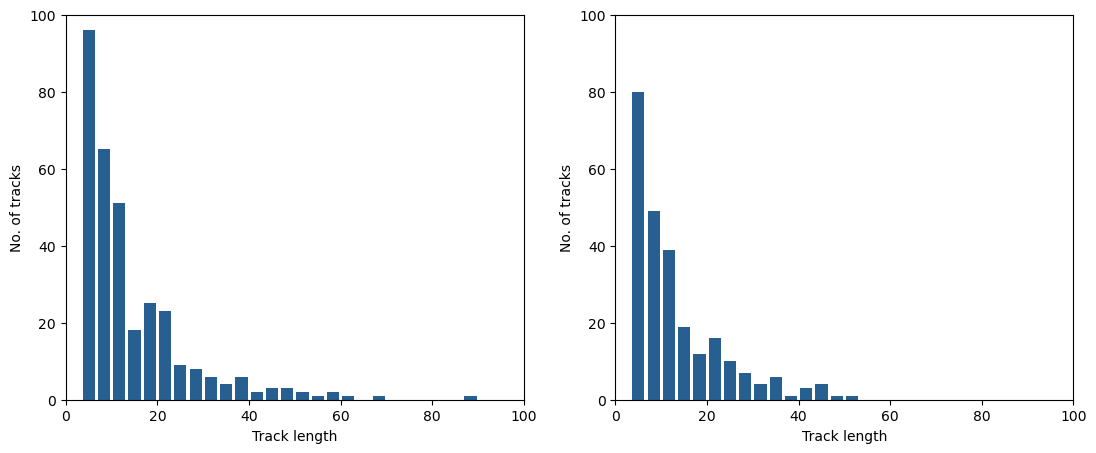

In [36]:
# Plots distribution of track lenghts

fig, ax = plt.subplots(1,2, figsize = (13,5)) # ; sign removes output lines
ax[0].hist(D14_merged_allROIs_tracklen, np.linspace(0,100,31), rwidth = 0.8, color='#275f90'); #np.linspace() sets number of bins
ax[1].hist(D14_raw_allROIs_tracklen, np.linspace(0,100,31), rwidth = 0.8, color='#275f90');
ax[0].set_ylim(0,100);
ax[1].set_ylim(0,100);
ax[0].set_xlim(0,100);
ax[1].set_xlim(0,100);
ax[0].set_xlabel('Track length');
ax[1].set_xlabel('Track length');
ax[0].set_ylabel('No. of tracks');
ax[1].set_ylabel('No. of tracks');

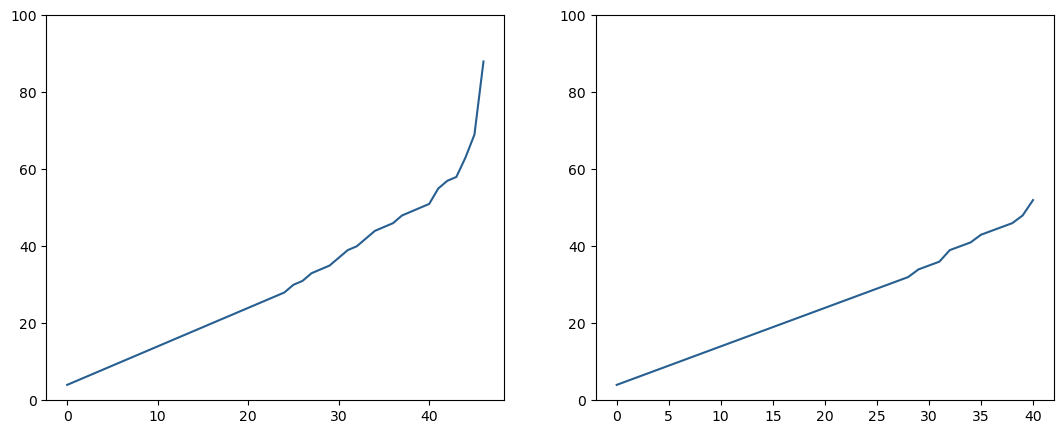

In [73]:
# Plots track lengths in line plots

D14_merged_allROIs_tracklenuni = list(set(D14_merged_allROIs_tracklen)) # set() gets unique elements of list
D14_raw_allROIs_tracklenuni = list(set(D14_raw_allROIs_tracklen))       # set() gets unique elements of list

fig, ax = plt.subplots(1,2, figsize = (13,5)) # ; sign removes output lines
ax[0].plot(D14_merged_allROIs_tracklenuni, color='#275f90');
ax[1].plot(D14_raw_allROIs_tracklenuni, color='#275f90');
ax[0].set_ylim(0,100);
ax[1].set_ylim(0,100);

In [48]:
D14_merged_allROIs_meantracklen = np.mean(D14_merged_allROIs_tracklen).round(2)
D14_raw_allROIs_meantracklen = np.mean(D14_raw_allROIs_tracklen).round(2)

print(D14_merged_allROIs_meantracklen)
print(D14_raw_allROIs_meantracklen)

14.05
12.93


In [51]:
np.std(D14_merged_allROIs_tracklen).round(2)


12.28

In [52]:
np.std(D14_raw_allROIs_tracklen).round(2)

10.08